In [1]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "6"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
import joblib

In [3]:
dt = pd.read_csv("C:\\Users\\Eric\\Documents\\project\\fraud_detection\\dataset\\creditcard.csv")

In [4]:
dt.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
dt.shape

(284807, 31)

In [7]:
dt['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [8]:
# Check for class imbalance
class_0 = dt[dt['Class'] == 0]
class_1 = dt[dt['Class'] == 1]
imbalance_ratio = len(class_1) / (len(class_0) + len(class_1))
imbalance_ratio

0.001727485630620034

In [9]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

X = dt.drop(['Class'], axis=1)
y = dt['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocessor = ColumnTransformer([
    ("scaler", RobustScaler(), ['Amount', 'Time'])
], remainder='passthrough')
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(k_neighbors=3, random_state=42)),
    ("xgb", XGBClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
xgb_acc = accuracy_score(y_test, y_pred)
xgb_report = classification_report(y_test, y_pred)
xgb_cm = confusion_matrix(y_test, y_pred)

# precision: Out of all fraud, how many did we correctly identify?
# recall: Out of the flagged transactions, how many were actually fraud?
print(f"XGBoost Accuracy: {xgb_acc}")
print("XGBoost Classification Report:")
print(xgb_report)
print("XGBoost Confusion Matrix:")
print(xgb_cm)





XGBoost Accuracy: 0.9994382219725431
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.88      0.84        98

    accuracy                           1.00     56962
   macro avg       0.91      0.94      0.92     56962
weighted avg       1.00      1.00      1.00     56962

XGBoost Confusion Matrix:
[[56844    20]
 [   12    86]]


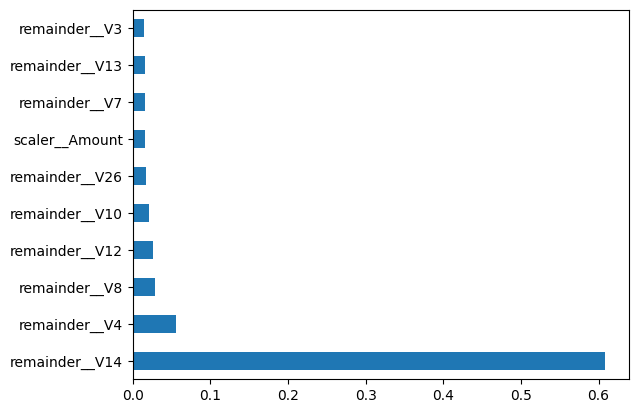

In [10]:
# To get your feature importance after fitting:
import matplotlib.pyplot as plt

# Get names from preprocessor (scaled ones + passthrough ones)
ohe_cols = pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = pipeline.named_steps['xgb'].feature_importances_

# Plotting the top 10
feat_importances = pd.Series(importances, index=ohe_cols)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

In [11]:
joblib.dump(pipeline, 'fraud_pipeline.pkl')
print("Model saved as fraud_pipeline.pkl")


Model saved as fraud_pipeline.pkl
